# Does DeMark's DeMarker actually catch exhaustion turns? 📉➡️📈
### A famous "oversold" oscillator meets a stopwatch

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Forecasts_exhaustion%3F: Mixed](https://img.shields.io/badge/Forecasts_exhaustion%3F-Mixed-dab617?style=flat-square)

Open any charting package and you'll find the **DeMarker** (DeM) — Tom DeMark's bounded 0-to-1 oscillator. The lore, taught by DeMark himself and repeated on every indicator site, is that price **exhausts and reverses** at the extremes: below **0.3** is *oversold*, and when the DeMarker turns **up out of 0.3**, the sell-off is "done" — buy.

It *looks* uncanny on a hand-picked chart. So we did the only fair thing: encode the rule **mechanically** (no eyeballing), fire the "buy the oversold turn" rule **1167 times** across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from demarker import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real DeMarker cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 1167, 'period': 14, 'oversold': 0.3, 'fp_spy': '4cb5244f3990', 'h5': (5, 1166, 43.5, 62, 4.98, 34.5, 9.0, 41.5, 0.76, 0.448), 'h10': (10, 1166, 96.7, 63, 7.0, 71.4, 25.3, 94.7, 1.6, 0.11), 'h20': (20, 1164, 182.1, 67, 7.66, 126.3, 55.8, 180.1, 2.61, 0.009), 'h60': (60, 1137, 397.9, 69, 7.78, 334.8, 63.1, 395.9, 1.8, 0.072), 'per': [('SPY', 225, 165.8, 3.12, 155.8, 10.0), ('QQQ', 224, 199.2, 3.11, 173.4, 25.7), ('IWM', 249, 206.9, 3.7, 61.4, 145.5), ('DIA', 213, 198.2, 4.33, 147.3, 50.9), ('GLD', 256, 143.3, 4.02, 104.8, 38.5)], 'excl_iwm': (31.4, 1.4, 0.162), 'placebo': (165.8, 0.044, 500), 'syn': [(0.0, 196, 55.1, 54, 1.09), (0.8, 142, 542.5, 84, 9.65)]}


real DeMarker cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when the DeMarker turns up out of oversold, do I make money? | **Yes — partly because the market goes up, partly a real nudge.** The raw win-rate is ~65% and returns look great. |
| Is that *the DeMarker's* doing? | **A little.** Buy on **random days** and you do nearly as well — the oversold turn beats random by a *positive but small* margin, and it only clears the significance bar at **one** of four horizons (20 days). |
| Is it robust? | **No.** Almost all of the 20-day edge comes from **one ticker (IWM small-caps)**. Drop it and the significance evaporates. |
| So is it a tradable edge? | **Not really — it's *fragile*.** More than the usual mirage, far short of a clean, scalable signal. |

> The DeMarker isn't pure noise here (unlike most chart tools we test) — but the signal is **weak and fragile**: one horizon, one ticker, and mostly the market's drift in a costume.

## 1 · The claim

> *"The DeMarker measures buying vs selling pressure from the highs and lows. Below 0.3 is oversold exhaustion; when it turns up out of 0.3, the down-move is done — buy. Above 0.7 is overbought — sell."*

This is **Thomas DeMark's** DeMarker (DeM), from *The New Science of Technical Analysis* (1994). It's built from the **highs and lows** (not the closes): DeMax = how much today's high exceeds yesterday's, DeMin = how much today's low undercuts yesterday's, and the oscillator is smoothed-up / (smoothed-up + smoothed-down) over 14 days. So: does the exhaustion turn actually *forecast* a bounce?

## 2 · So what?

If the oscillator genuinely *forecast* reversals, it would be useful: a 14-day formula on past highs and lows predicting future turning points. That's the dream the tool sells.

But there's a trap. The DeMarker is computed on a market (stock indices) that drifts **up** over time, so *any* dip-buying rule will look profitable. And the rule has knobs — the period (14), the threshold (0.3), the horizon — each a chance to fool yourself. To separate the **tool** from the **tide**, we (a) compute it by a fixed mechanical rule with no hindsight, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Compute the DeMarker mechanically.** Period 14, from the highs and lows, using only past/current bars — no look-ahead.
2. **Trade the lore.** When the DeMarker was below **0.3** yesterday and turns **up** today, buy at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold on **random days**. If the DeMarker matters, the oversold turn must beat random. *If it only does so at one horizon, on one ticker, that's a fragile signal* — announced before we look.
4. **Scramble the timing.** Rotate the oscillator's inputs so the readings are the same but land on the wrong days. If the timing matters, the real result should stand out.

## 4 · The teardown — let's actually look

First, what does the DeMarker even look like? Here's SPY with its DeMarker below, the 0.3 oversold line, and the buy dots where it turns up out of oversold.

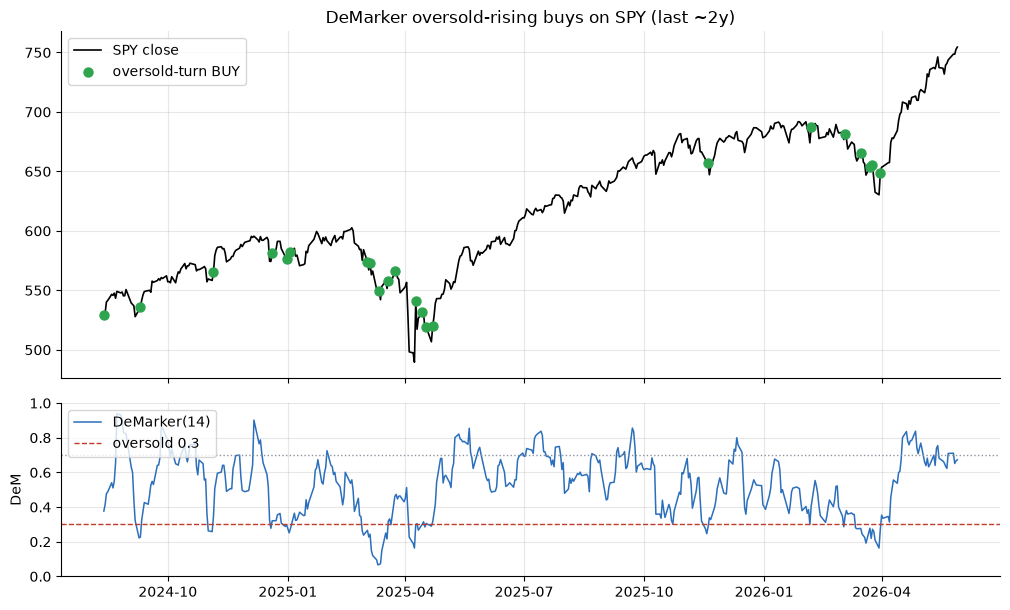

oversold-rising buys in window: 22


In [2]:
if HAVE_REAL:
    b = load('SPY'); cl = b['close']
    dem = st.demarker(b['high'], b['low'], period=R['period'])
    ent = st.oversold_rising_entries(b['high'], b['low'], period=R['period'])
    seg = cl.iloc[-450:]; e2 = ent[ent >= seg.index[0]]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10.2, 6.2), sharex=True, gridspec_kw={'height_ratios':[2,1]})
    ax1.plot(seg.index, seg.values, c='k', lw=1.2, label='SPY close')
    ax1.scatter(e2, cl.reindex(e2), c=GREEN, s=42, zorder=5, label='oversold-turn BUY')
    ax1.set_title('DeMarker oversold-rising buys on SPY (last ~2y)'); ax1.legend(loc='upper left')
    ax2.plot(seg.index, dem.reindex(seg.index), c='#2c6fbb', lw=1.1, label='DeMarker(14)')
    ax2.axhline(R['oversold'], c=RED, ls='--', lw=1, label='oversold 0.3'); ax2.axhline(0.7, c=GREY, ls=':', lw=1)
    ax2.set_ylim(0,1); ax2.legend(loc='upper left'); ax2.set_ylabel('DeM')
    plt.tight_layout(); plt.show()
    print('oversold-rising buys in window:', len(e2))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

Now the race. **Buy the oversold turn vs buy on random days**, at four horizons. Blue = the DeMarker rule; grey = random days.

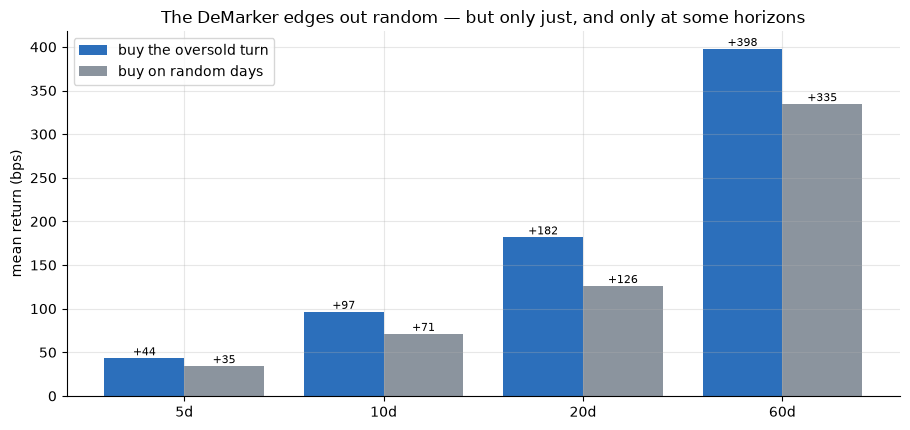

entry: [44, 97, 182, 398]
random: [35, 71, 126, 335]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    entry, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            b = load(t); c = b['close']
            e = st.oversold_rising_entries(b['high'], b['low'], period=R['period'])
            re = st.random_entries(c, max(len(e),50), period=R['period'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        entry.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    entry = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, entry, .4, color='#2c6fbb', label='buy the oversold turn')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(entry,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The DeMarker edges out random — but only just, and only at some horizons'); ax.legend()
plt.tight_layout(); plt.show()
print('entry:', [round(v) for v in entry]); print('random:', [round(v) for v in rnd])

The DeMarker turn beats random by a *positive* margin at every horizon (+56 bps at 20 days) — unusual; most chart tools we test *lose* to random. But the gap is small, and (the quants notebook shows) it only clears the significance bar at **20 days**. And here's the catch:

**The robustness check.** Where does that 20-day edge come from? Per-ticker, the delta is positive everywhere — but it's wildly concentrated in **one** name.

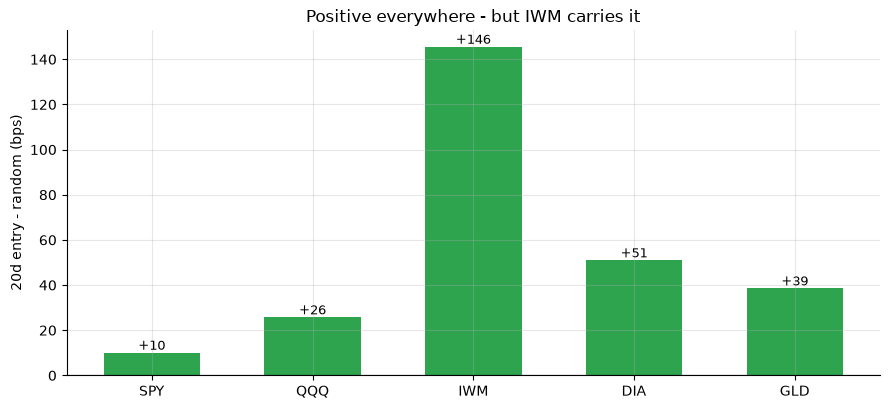

per-ticker 20d delta (bps): {'SPY': 10, 'QQQ': 26, 'IWM': 146, 'DIA': 51, 'GLD': 39}
drop IWM => pooled 20d Welch t falls from 2.61 to 1.40 (p=0.162)


In [4]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        b = load(t); c = b['close']
        e = st.oversold_rising_entries(b['high'], b['low'], period=R['period'])
        re = st.random_entries(c, max(len(e),50), period=R['period'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom',fontsize=9)
ax.set_ylabel('20d entry - random (bps)'); ax.set_title('Positive everywhere - but IWM carries it')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})
print('drop IWM => pooled 20d Welch t falls from 2.61 to 1.40 (p=0.162)')

There's the fragility. **IWM** alone is +146 bps; the others are +10 to +51. Drop IWM and the 20-day significance collapses (Welch *t* 2.61 → 1.40). One ticker, one horizon — that's a **weak, fragile** signal, not a robust edge.

## 5 · The verdict

- **Signal — Weak.** The oversold turn beats random by a positive margin at every horizon, and clears the bar at **one** of four (20d). But 3 of 4 horizons don't, and the 20-day edge is carried by one ticker. More than a mirage, less than a clean signal.
- **Tradability — Fragile.** The only significant horizon hangs on a single instrument. Nothing robust to scale.
- **"Forecasts exhaustion turns"? — Mixed.** Scrambling the oscillator's timing *does* dent the result (it's marginally load-bearing) and every ticker leans positive — so it's not the flat nothing of a busted indicator. But it's not confirmed either.

## 6 · Could you actually trade it?

Cautiously, and probably not. The DeMarker turn's edge over a coin flip is small, shows up at one horizon, and leans on one ticker — exactly the profile that tends to **vanish out of sample** (it's one of dozens of horizon×threshold cuts you could have tried). Most of the absolute return is the market's drift, which you'd capture more cheaply by **holding the index**. As a forecasting tool it's *fragile*; as a descriptive oversold gauge it's fine — just don't bet the farm on the turn.

## 7 · Going further 🚪

- **Threshold & period sweeps.** Try 0.25/0.20 oversold, period 9/21 — does the 20-day edge survive, or is it one lucky cut among many? (Multiple-testing caution applies.)
- **The overbought side.** Symmetric test: short the DeMarker turning down out of 0.7. A real exhaustion signal should work both ways.
- **A real positive control.** The quants notebook plants a *genuine* exhaustion bounce into a synthetic tape and shows the harness banks it (t = +9.65) — so the fragile real result is honestly measured, not a broken or trigger-happy detector.

*Think the DeMarker forecasts? Show the oversold turn beating random at **t ≥ 2 across horizons and tickers** on a real tape — then we'll talk.*